In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from datetime import datetime
import os


# 1.- Visualiza años seguidos entre train y test

In [3]:
# Visualizo todas las fechas separando las de entrenamiento con las de verificación

def visualiza_years_seguidos(df:pd.DataFrame, name:str):
        """Genera una visualización del precio de cierre de una acción mostrando todo el histórico
    y destacando los últimos años disponibles en el DataFrame. Permite comparar visualmente
    la evolución reciente con el comportamiento histórico.

    El gráfico incluye:
    - Todo el histórico de precios en color gris.
    - Los últimos dos años disponibles en el DataFrame resaltados en color rojo.
    - Ejes de fecha y precio, cuadrícula y leyenda descriptiva.

        Args:
            df (pd.DataFrame): DataFrame con al menos las columnas:
            - 'date': fechas en formato datetime o convertible a datetime.
            - 'year': año correspondiente a cada fila.
            - 'close': precio de cierre diario.
            name (str): Nombre de la acción para mostrar en el título del gráfico.
        """
        # Asegurar que date es datetime
        df["date"] = pd.to_datetime(df["date"])

        # Detectar los dos últimos años
        ultimos_dos = sorted(df["year"].unique())[-2:]

        plt.figure(figsize=(12,5))

        # 1. Pintar TODO el histórico en gris
        plt.plot(df["date"], df["close"], color="lightgray", label="Histórico")

        # 2. Pintar los dos últimos años en rojo
        df_ultimos = df[df["year"].isin(ultimos_dos)]
        plt.plot(df_ultimos["date"], df_ultimos["close"], color="red", linewidth=2,
                label=f"Últimos años: {ultimos_dos[0]} y {ultimos_dos[1]}")

        plt.title(f"{name}. Precio de cierre")
        plt.xlabel("Fecha")
        plt.ylabel("Precio ($)")
        plt.grid(True)
        plt.legend()
        plt.show()



# 2.- Visualiza cierre años separados

In [4]:
# Visualizo todos los años sobre el mismo eje x de todos los dias del año (incluido el 29-2 para bisiestos)

def visualiza_years_separados(df:pd.DataFrame, name:str):
    """Genera un gráfico donde cada año del DataFrame se representa como una línea
    independiente sobre un mismo eje X basado en el día del año (formato MM-DD).
    Esto permite comparar visualmente la estacionalidad del precio de cierre entre
    distintos años, incluyendo años bisiestos (se conserva el 29 de febrero).

    El gráfico incluye:
    - Una línea por cada año, cada una con un color distinto.
    - El eje X representado como mes-día (MM-DD), ordenado de enero a diciembre.
    - Etiquetas de meses abreviadas en español.
    - Leyenda con todos los años representados.

    Args:
        df (pd.DataFrame): DataFrame con al menos las columnas:
            - 'date': fechas en formato datetime.
            - 'year': año correspondiente a cada fila.
            - 'close': precio de cierre diario.
        name (str): Nombre de la acción para mostrar en el título del gráfico.
    """

    # Crear columna mes-día (formato MM-DD)
    df["md"] = df["date"].dt.strftime("%m-%d")

    # Ordenar por mes-día para que el eje X vaya de enero a diciembre
    df = df.sort_values(["md", "year"])

    plt.figure(figsize=(14,6))

    # Lista de años
    years = sorted(df["year"].unique())
    n_years = len(years)

    # Paleta con tantos colores como años
    cmap = plt.colormaps["nipy_spectral"].resampled(n_years)



    # Dibujar una línea por año con color único
    for i, y in enumerate(years):
        df_y = df[df["year"] == y]
        plt.plot(df_y["md"], df_y["close"], label=str(y), color=cmap(i))

    # === Ticks grandes: primeros días de cada mes ===
    meses = pd.date_range("2001-01-01", "2001-12-01", freq="MS")
    ticks_meses = meses.strftime("%m-%d")

    # Abreviaturas de meses en español
    labels_meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
                    "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

    plt.xticks(ticks=ticks_meses, labels=labels_meses, fontsize=12)

    plt.title(f"{name}. Precio de cierre por dia y mes del año")
    plt.xlabel("Mes")
    plt.ylabel("Close ($)")
    plt.grid(True)
    plt.legend(ncol=15, fontsize=7)
    plt.show()



# 3.- Visualiza beneficio acum. años separados

In [ ]:
# Visualizar beneficio acumulado

def visualiza_beneficio_acum(df:pd.DataFrame, name:str):
    """Representa el rendimiento acumulado de cada año sobre un mismo eje X basado en el
    día del año (formato MM-DD). Permite comparar visualmente cómo evoluciona el
    beneficio acumulado anual a lo largo del calendario, incluyendo años bisiestos.

    El gráfico incluye:
    - Una línea por cada año, cada una con un color distinto.
    - El eje X representado como mes-día (MM-DD), ordenado de enero a diciembre.
    - Etiquetas de meses abreviadas en español.
    - Leyenda con todos los años representados.
    - Cuadrícula y título descriptivo.

    Args:
        df (pd.DataFrame): DataFrame con al menos las columnas:
            - 'md': día del año en formato MM-DD.
            - 'year': año correspondiente a cada fila.
            - 'rendimiento_acumulado': rendimiento acumulado diario respecto al día 0.
        name (str): Nombre de la acción para mostrar en el título del gráfico.
    """
    
    plt.figure(figsize=(14,6))
    
    # Lista de años
    years = sorted(df["year"].unique())
    n_years = len(years)
    
    # Paleta con tantos colores como años
    cmap = plt.colormaps["nipy_spectral"].resampled(n_years)

    # Dibujar una línea por año con color único
    for i, y in enumerate(years):
        df_y = df[df["year"] == y]
        plt.plot(df_y["md"], df_y["rendimiento_acumulado"], label=str(y), color=cmap(i))

    # === Ticks grandes: primeros días de cada mes ===
    meses = pd.date_range("2001-01-01", "2001-12-01", freq="MS")
    ticks_meses = meses.strftime("%m-%d")

    # Abreviaturas de meses en español
    labels_meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
                    "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

    plt.xticks(ticks=ticks_meses, labels=labels_meses, fontsize=12)

    plt.title(f"{name}. Beneficio acumulado por dia del año")
    plt.xlabel("Mes")
    plt.ylabel("Rendimiento")
    plt.grid(True)
    plt.legend(ncol=15, fontsize=7)
    plt.show()

# 4.- Visualiza media por dia

In [6]:
# Visualizo esta media en un plotly interactivo

def visualiza_beneficio_acum_medio(df:pd.DataFrame, name:str):
    """Genera un gráfico interactivo con Plotly que muestra el rendimiento medio acumulado
    histórico diario de una acción, calculado a partir del conjunto de entrenamiento
    (por ejemplo, 2000–2023). El gráfico utiliza un eje temporal ficticio basado en un
    año bisiesto para representar correctamente todos los días del año, incluido el 29
    de febrero.

    El gráfico incluye:
    - Línea del rendimiento medio acumulado diario expresado en porcentaje.
    - Eje X con meses abreviados en español.
    - Hover informativo mostrando fecha (día-mes) y rendimiento medio.
    - Línea vertical roja indicando el día actual dentro del calendario.
    - Estilo limpio con plantilla “plotly_white”.

    Args:
        df (pd.DataFrame): ataFrame con al menos las columnas:
            - 'md': día del año en formato MM-DD.
            - 'rendimiento_medio': rendimiento medio acumulado (valor decimal).
        name (str): Nombre de la acción para mostrar en el título del gráfico.
    """
    # === Preparar datos ===
    df_plot = df.reset_index()[["md", "rendimiento_medio"]] #nuevo DF con nuevo indice y solo las columnas md y rendimiento_medio
    df_plot["fecha"] = pd.to_datetime("2000-" + df_plot["md"], format="%Y-%m-%d") # creo columna fecha real para el eje x con un año cualquiera bisiesto
    df_plot = df_plot.sort_values("fecha") # Ordena la fecha cronologicamente
    df_plot["rendimiento_medio_pct"] = df_plot["rendimiento_medio"] * 100  # convierte la media en %

    # === Crear figura ===
    fig = px.line(
        df_plot,
        x="fecha",
        y="rendimiento_medio_pct",
        title=f"{name}. Rendimiento medio acumulado histórico diario (2000 al 2023)",
    )

    # === Ticks de meses en español para el eje X ===
    meses = pd.date_range("2000-01-01", "2000-12-01", freq="MS")
    fig.update_xaxes(
        tickmode="array",
        tickvals=meses,
        ticktext=["Ene","Feb","Mar","Abr","May","Jun",
                "Jul","Ago","Sep","Oct","Nov","Dic"]
    )

    # === Hover o cuandro emergente al pasar el ratón sin año ===
    fig.update_traces(
        hovertemplate="Fecha: %{x|%d-%m}<br>Rendimiento medio: %{y:.2f}%<extra></extra>",  # br es un salto de linea
        line=dict(color="black", width=2)
    )

    # === Día actual ===
    hoy = datetime.now()
    md_actual = hoy.strftime("%m-%d")
    fecha_actual = pd.to_datetime("2000-" + md_actual)

    # === Línea vertical roja corta (shape) ===
    fig.add_shape(
        type="line",
        x0=fecha_actual,
        x1=fecha_actual,
        y0=df_plot["rendimiento_medio_pct"].min(),     # parte baja
        y1=df_plot["rendimiento_medio_pct"].max(),  # más corta
        line=dict(color="red", width=2)
    )

    # === Etiqueta "Hoy" justo encima de la línea ===
    fig.add_annotation(
        x=fecha_actual,
        y=df_plot["rendimiento_medio_pct"].max() * 1.05,
        text="Hoy",
        showarrow=False,
        font=dict(color="red", size=14)
    )

    # === Estilo general ===
    fig.update_layout(
        xaxis_title="Mes",
        yaxis_title="Rendimiento medio (%)",
        template="plotly_white",
        showlegend=False
    )

    fig.show();



# 5.- Importar ficheros tratados

In [7]:

# importar los ficheros con los datos ya tratados

def importar_files_tratados(name: str, ticker: str, input_folder: str)->tuple:
    """Importa desde disco los ficheros Parquet generados en el proceso de tratamiento
    de datos (df, df_train y df_validacion). Cada fichero se carga de forma
    independiente y con manejo de errores para informar si alguno no está disponible.

    Para cada archivo:
    - Intenta cargar el fichero correspondiente al DataFrame.
    - Si no existe, muestra un mensaje indicando que no se encontró.
    - Si ocurre otro tipo de error, muestra un aviso con la causa.
    - En caso de error, la variable correspondiente se devuelve como None.

    Los ficheros esperados son:
    - `{name}_{ticker}_df.parquet`
    - `{name}_{ticker}_train.parquet`
    - `{name}_{ticker}_validacion.parquet`

    Args:
        name (str): Nombre de la empresa (por ejemplo, "Amazon").
        ticker (str): Ticker bursátil de la empresa (por ejemplo, "AMZN").
        input_folder (str): Carpeta donde se encuentran los ficheros Parquet tratados.

    Returns:
        _type_: tuple:
            df (pd.DataFrame | None): DataFrame principal con datos diarios tratados.
            df_train (pd.DataFrame | None): DataFrame de entrenamiento (2000–2023).
            df_validacion (pd.DataFrame | None): DataFrame de validación (2024 en adelante).
            Si algún fichero no se encuentra o falla al cargar, se devuelve como None.
    """
    
    try:
        df = pd.read_parquet(f"{input_folder}/{name}_{ticker}_df.parquet")
    except FileNotFoundError:
        print(f"❌ No se encontró el archivo: {name}_{ticker}_df.parquet")
        df = None
    except Exception as e:
        print(f"⚠️ Error al cargar {name}_{ticker}_df.parquet: {e}")
        df = None

    try:
        df_train = pd.read_parquet(f"{input_folder}/{name}_{ticker}_train.parquet")
    except FileNotFoundError:
        print(f"❌ No se encontró el archivo: {name}_{ticker}_train.parquet")
        df_train = None
    except Exception as e:
        print(f"⚠️ Error al cargar {name}_{ticker}_train.parquet: {e}")
        df_train = None

    try:
        df_validacion = pd.read_parquet(f"{input_folder}/{name}_{ticker}_validacion.parquet")
    except FileNotFoundError:
        print(f"❌ No se encontró el archivo: {name}_{ticker}_validacion.parquet")
        df_validacion = None
    except Exception as e:
        print(f"⚠️ Error al cargar {name}_{ticker}_validacion.parquet: {e}")
        df_validacion = None

    return df, df_train, df_validacion


# 100.- principal

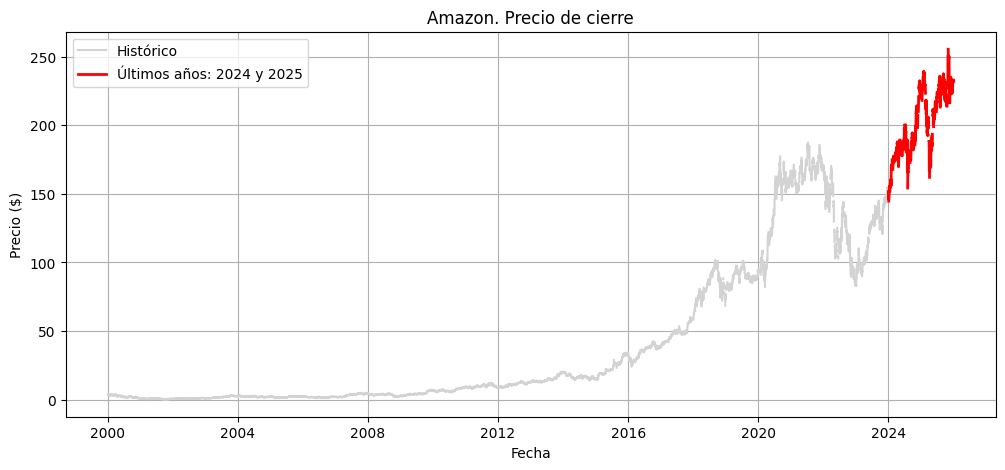

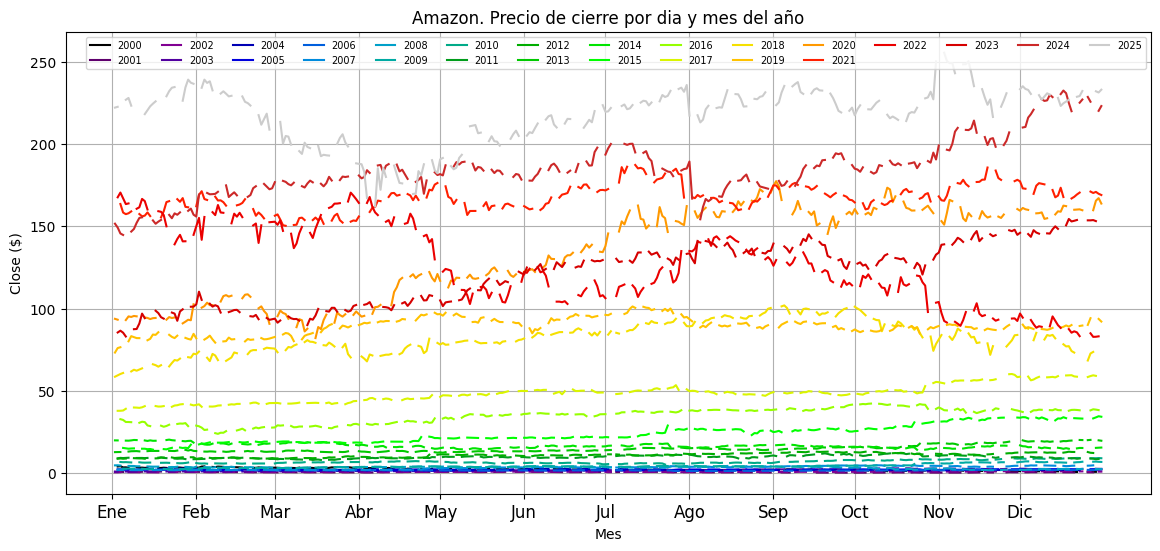

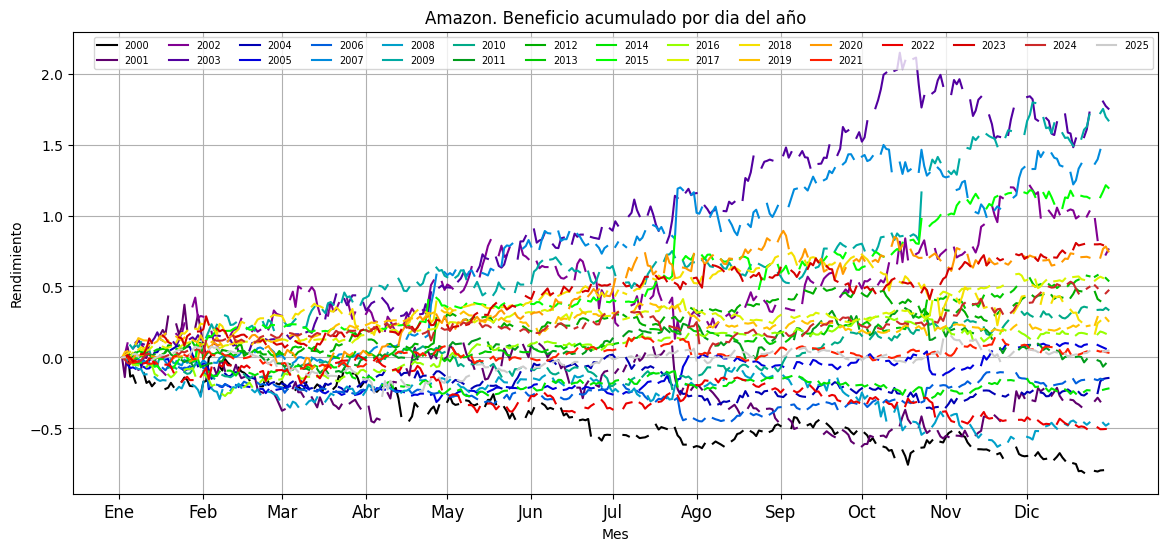

In [8]:
"""
Ejecuta el análisis visual completo de la estacionalidad de una acción concreta del
SP500 Top 25 utilizando los datos previamente tratados. El objetivo es explorar el
comportamiento histórico del activo a través de varias visualizaciones clave que
permiten identificar patrones, tendencias y posibles pautas estacionales.

El flujo del script incluye:

1. Carga de datos tratados:
    - Se importan los ficheros correspondientes a la acción seleccionada (train y
      validación), que contienen los rendimientos acumulados por día del año y por año.
    - Se obtiene un DataFrame combinado con todos los años disponibles.

2. Visualización de años consecutivos:
    - Se muestra la evolución del rendimiento acumulado año a año en orden cronológico,
      permitiendo observar cómo ha cambiado el comportamiento del activo a lo largo del tiempo.

3. Visualización de todos los años superpuestos:
    - Se representan todos los años sobre el mismo eje temporal (días del año), lo que
      facilita detectar patrones estacionales repetitivos, divergencias y anomalías.
    - Se incluyen años bisiestos manteniendo el día 29-02 para conservar la alineación.

4. Visualización del beneficio acumulado por día:
    - Se muestra el rendimiento acumulado de cada año comenzando desde cero, lo que
      permite comparar la forma de las curvas sin depender del nivel inicial.

5. Visualización del beneficio acumulado medio:
    - Se calcula y representa la media del rendimiento acumulado diario de todos los
      años del conjunto de entrenamiento.
    - Esta curva media es útil para identificar la estacionalidad general del activo
      y detectar periodos históricamente favorables o desfavorables.

Este script sirve como punto de partida para comprender la estructura estacional de
una acción antes de realizar análisis más avanzados como búsqueda de pautas,
validación o backtesting.
"""


input_folder = "SP500_Top25_tratados"
name = "Amazon"
ticker = "AMZN"

# 0.- importar los ficheros ya tratados
df, df_train, df_validacion = importar_files_tratados(name, ticker, input_folder)

# 1.- Visualizo el total de años separados entre train y test
visualiza_years_seguidos(df, name)

# 2.- Visualizo todos los años sobre el mismo eje x de todos los dias del año (incluido el 29-2 para bisiestos)
visualiza_years_separados(df, name)

# 5.- Visualiza beneficio acumulado por dia empezando en cero
visualiza_beneficio_acum(df, name)

# 9.- Visualiza media por dia del beneficio acumulado de todos los años
visualiza_beneficio_acum_medio(df_train, name)